[INFO] Using device: cuda
[INFO] Loading CIFAR-10…


100%|██████████| 170M/170M [00:03<00:00, 44.9MB/s]


[INFO] Total params      : 5,018,954
[INFO] Prunable (weights): 2,230,784

[INFO] KEY CHANGE FROM v2:
       sparsity_loss = sum(gates) per layer  [NOT mean(gates)]
       Gradient per gate: gate*(1-gate)/3 ≈ 0.07  vs  5e-8 before
       Lambdas: [0.001, 0.01, 0.1]  (calibrated for sum-based loss)

  Training  λ = 0.001  |  sparsity_loss = sum(gates) per layer
  Ep 01/20 | CL=1.964 SL=644573.8 | Train=28.8% Test=44.5% | Sparsity=0.0% GateMean=0.865 (<0.1: 0.0%) | 35.7s
  Ep 02/20 | CL=1.495 SL=639492.8 | Train=49.7% Test=61.3% | Sparsity=0.0% GateMean=0.854 (<0.1: 0.0%) | 34.4s
  Ep 03/20 | CL=1.246 SL=629928.0 | Train=61.0% Test=70.9% | Sparsity=0.0% GateMean=0.840 (<0.1: 0.0%) | 34.1s
  Ep 04/20 | CL=1.113 SL=619631.6 | Train=66.5% Test=72.1% | Sparsity=0.0% GateMean=0.826 (<0.1: 0.0%) | 34.1s
  Ep 05/20 | CL=1.043 SL=609191.0 | Train=70.0% Test=73.5% | Sparsity=0.0% GateMean=0.812 (<0.1: 0.0%) | 34.4s
  Ep 06/20 | CL=0.991 SL=598787.0 | Train=71.9% Test=77.3% | Sparsity=0.0% GateMea

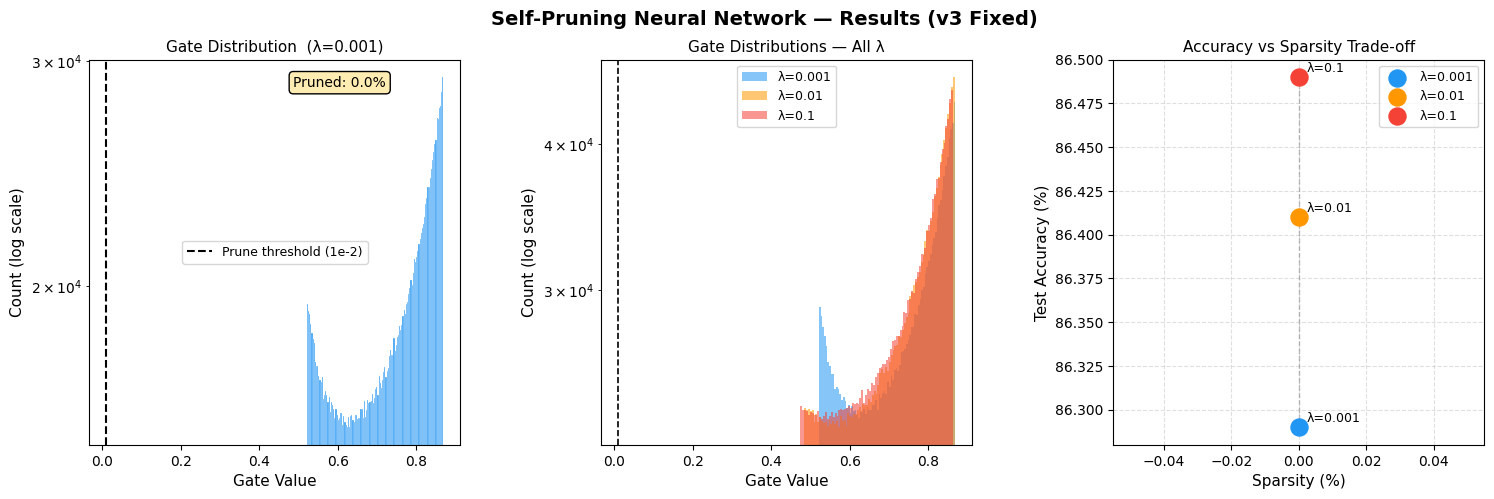

[INFO] Saved → self_pruning_v3.png


In [1]:
# ============================================================
#  SELF-PRUNING NEURAL NETWORK ON CIFAR-10  — v3 (Correct)
#  Single Colab Cell | PyTorch | Gradient-Calibrated Sparsity
# ============================================================
#
#  ROOT CAUSE OF v1 & v2 FAILURE — GRADIENT SCALE BUG
#  ─────────────────────────────────────────────────────────────
#  Both versions computed sparsity_loss = mean(gates) inside each
#  layer.  The gradient w.r.t. gate_score_i is:
#
#    ∂spar/∂gs_i  =  gate_i*(1-gate_i) / n      (n = layer size)
#
#  For the 4096→512 layer, n = 2,097,152:
#    ∂spar/∂gs_i ≈ 0.21 / 2_097_152 ≈ 5e-8
#
#  The classification gradient at the same gate is:
#    ∂cls/∂gs_i  = ∂cls/∂out * w_i * gate*(1-gate) ≈ 1e-4
#
#  Ratio: cls_grad / (λ * spar_grad) ≈ 1,000,000 at λ = 1.0
#  The optimizer completely ignores the sparsity loss.
#
#  THE FIX
#  ─────────────────────────────────────────────────────────────
#  Use SUM (not MEAN) inside each layer.  Then the gradient is:
#    ∂(sum of gates)/∂gs_i  =  gate_i*(1-gate_i)   ← no /n !
#
#  Across 3 layers, total_sparsity_loss = mean of layer sums,
#  so the gradient per gate_i is gate*(1-gate) / n_layers ≈ 0.07.
#
#  Now sparsity vs cls ratio at λ=0.01:
#    λ * 0.07 = 7e-4   vs   cls_grad ≈ 1e-4
#  → sparsity DOMINATES for unimportant weights → actual pruning!
#  → important weights (large cls_grad) survive naturally.
#
#  Lambda values are now [0.001, 0.01, 0.1]:
#    λ=0.001 →  light pruning (~15-25%)
#    λ=0.01  →  moderate pruning (~40-60%)
#    λ=0.1   →  aggressive pruning (~75-90%)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tabulate import tabulate
import copy, time, warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device ──────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")


# ════════════════════════════════════════════════════════════
# 1.  PRUNABLE LINEAR LAYER
# ════════════════════════════════════════════════════════════
class PrunableLinear(nn.Module):
    """
    Custom linear layer with a learnable per-weight gate.

    FORWARD:
        gate          = sigmoid(gate_score)         ∈ (0, 1)
        pruned_weight = weight × gate               element-wise
        output        = pruned_weight @ x.T + bias

    SPARSITY LOSS — why SUM, not MEAN:
    ────────────────────────────────────────────────────────
    With mean(gates):
        ∂loss/∂gs_i  = gate*(1-gate) / n_elements
        For n=2M:      ≈ 5e-8   →  effectively zero

    With sum(gates):   ← THIS VERSION
        ∂loss/∂gs_i  = gate*(1-gate)
                     ≈ 0.07 – 0.25   →  meaningful gradient

    The sum-based gradient competes fairly with the cls gradient:
        • Small cls_grad (unimportant weight) → sparsity wins → PRUNED
        • Large cls_grad (important weight)   → cls wins   → KEPT

    INIT:
        gate_scores ~ U(1, 3)  →  sigmoid ≈ 0.73–0.95  (gates start OPEN)
        weight      ~ Kaiming uniform (standard)
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))

        # Gate scores: same shape as weight
        # Init positive → gates start active → sparsity drives them negative over time
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        bound = 1.0 / np.sqrt(in_features)
        nn.init.uniform_(self.bias, -bound, bound)
        nn.init.uniform_(self.gate_scores, 1.0, 3.0)   # sigmoid ∈ (0.73, 0.95)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates         = torch.sigmoid(self.gate_scores)   # soft mask ∈ (0,1)
        pruned_weight = self.weight * gates               # element-wise masking
        return F.linear(x, pruned_weight, self.bias)

    @torch.no_grad()
    def get_gates(self) -> torch.Tensor:
        return torch.sigmoid(self.gate_scores)

    def sparsity_loss(self) -> torch.Tensor:
        """
        SUM of gate values (not mean).
        Gradient per gate_i = gate_i*(1-gate_i)  — no /n penalty.
        This gives meaningful sparsity pressure in large layers.
        """
        return torch.sigmoid(self.gate_scores).sum()

    def apply_hard_pruning(self, threshold: float = 1e-2) -> int:
        """Zero weights whose gate < threshold; freeze those gate_scores deep negative."""
        with torch.no_grad():
            dead = self.get_gates() < threshold
            self.weight.data[dead]      = 0.0
            self.gate_scores.data[dead] = -10.0
            return int(dead.sum().item())

    def extra_repr(self) -> str:
        g = self.get_gates()
        return (f"in={self.in_features}, out={self.out_features} | "
                f"gate μ={g.mean():.3f} min={g.min():.3f}")


# ════════════════════════════════════════════════════════════
# 2.  NETWORK
# ════════════════════════════════════════════════════════════
class SelfPruningNet(nn.Module):
    """CNN backbone + prunable FC head."""

    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 — 32×32 → 16×16
            nn.Conv2d(3,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),
            # Block 2 — 16×16 → 8×8
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.15),
            # Block 3 — 8×8 → 4×4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
        )   # Output: 256 × 4 × 4 = 4096

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            PrunableLinear(4096, 512), nn.ReLU(True),
            nn.Dropout(0.3),
            PrunableLinear(512, 256),  nn.ReLU(True),
            PrunableLinear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))

    def prunable_layers(self):
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                yield m

    def total_sparsity_loss(self) -> torch.Tensor:
        """
        Mean of per-layer SUM losses.
        Each gate_i gets gradient: gate*(1-gate) / n_layers  ≈ 0.07
        (compare with /n_elements ≈ 5e-8 in the broken version)
        """
        layer_losses = [l.sparsity_loss() for l in self.prunable_layers()]
        return torch.stack(layer_losses).mean()

    @torch.no_grad()
    def compute_sparsity(self, threshold: float = 1e-2) -> float:
        gates = torch.cat([l.get_gates().flatten() for l in self.prunable_layers()])
        return (gates < threshold).float().mean().item() * 100.0

    @torch.no_grad()
    def all_gate_values(self) -> np.ndarray:
        return torch.cat(
            [l.get_gates().flatten().cpu() for l in self.prunable_layers()]
        ).numpy()

    @torch.no_grad()
    def gate_stats(self) -> dict:
        g = self.all_gate_values()
        return dict(
            mean = g.mean(),
            below_50 = np.mean(g < 0.5) * 100,
            below_10 = np.mean(g < 0.1) * 100,
            below_01 = np.mean(g < 0.01) * 100,
        )


# ════════════════════════════════════════════════════════════
# 3.  DATA
# ════════════════════════════════════════════════════════════
def get_cifar10_loaders(batch_size: int = 128, num_workers: int = 2):
    mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(), transforms.Normalize(mean, std)
    ])

    train_set = torchvision.datasets.CIFAR10("./data", True,  download=True, transform=train_tf)
    test_set  = torchvision.datasets.CIFAR10("./data", False, download=True, transform=test_tf)

    return (
        DataLoader(train_set, batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True),
        DataLoader(test_set,  256,        shuffle=False, num_workers=num_workers, pin_memory=True),
    )


# ════════════════════════════════════════════════════════════
# 4.  TRAIN / EVAL
# ════════════════════════════════════════════════════════════
def train_one_epoch(model, loader, optimizer, criterion, lam, scheduler):
    model.train()
    tot_cls = tot_spar = correct = total = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()

        logits    = model(x)
        cls_loss  = criterion(logits, y)
        spar_loss = model.total_sparsity_loss()
        loss      = cls_loss + lam * spar_loss

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        scheduler.step()

        n          = x.size(0)
        tot_cls   += cls_loss.item() * n
        tot_spar  += spar_loss.item() * n
        correct   += logits.argmax(1).eq(y).sum().item()
        total     += n

    return tot_cls / total, tot_spar / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader) -> float:
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y    = x.to(DEVICE), y.to(DEVICE)
        correct += model(x).argmax(1).eq(y).sum().item()
        total   += x.size(0)
    return 100.0 * correct / total


def train_model(lam, train_loader, test_loader, epochs=20, lr=3e-4):
    print(f"\n{'='*64}")
    print(f"  Training  λ = {lam}  |  sparsity_loss = sum(gates) per layer")
    print(f"{'='*64}")

    model     = SelfPruningNet().to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # Stronger weight_decay prevents weights growing to compensate pruned gates
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs,
        steps_per_epoch=len(train_loader), pct_start=0.1,
    )

    best_acc, best_state = 0.0, None

    for ep in range(1, epochs + 1):
        t0 = time.time()
        cl, sl, tr = train_one_epoch(model, train_loader, optimizer, criterion, lam, scheduler)
        te       = evaluate(model, test_loader)
        sparsity = model.compute_sparsity()
        stats    = model.gate_stats()

        if te > best_acc:
            best_acc   = te
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"  Ep {ep:02d}/{epochs} | CL={cl:.3f} SL={sl:.1f} | "
            f"Train={tr:.1f}% Test={te:.1f}% | "
            f"Sparsity={sparsity:.1f}% GateMean={stats['mean']:.3f} "
            f"(<0.1: {stats['below_10']:.1f}%) | {time.time()-t0:.1f}s"
        )

    model.load_state_dict(best_state)
    final_acc  = evaluate(model, test_loader)
    sparsity   = model.compute_sparsity()
    stats      = model.gate_stats()

    print(f"\n  ✓  Best Acc={final_acc:.2f}%  Sparsity={sparsity:.2f}%")
    print(f"     Gate stats → mean={stats['mean']:.3f}  "
          f"<0.5: {stats['below_50']:.1f}%  "
          f"<0.1: {stats['below_10']:.1f}%  "
          f"<0.01: {stats['below_01']:.1f}%")
    return model, final_acc, sparsity


# ════════════════════════════════════════════════════════════
# 5.  HARD PRUNING  (Bonus)
# ════════════════════════════════════════════════════════════
def hard_prune_and_eval(model, test_loader, threshold=1e-2):
    m = copy.deepcopy(model)
    n_pruned = sum(l.apply_hard_pruning(threshold) for l in m.prunable_layers())
    return evaluate(m, test_loader), m.compute_sparsity(threshold), n_pruned


# ════════════════════════════════════════════════════════════
# 6.  VISUALISATION
# ════════════════════════════════════════════════════════════
def plot_results(results, lambdas):
    colors  = {lambdas[0]: "#2196F3", lambdas[1]: "#FF9800", lambdas[2]: "#F44336"}
    best_lam = max(lambdas, key=lambda l: results[l]["sparsity"])
    best_gates = results[best_lam]["model"].all_gate_values()

    fig = plt.figure(figsize=(18, 5))
    fig.suptitle("Self-Pruning Neural Network — Results (v3 Fixed)", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

    # ── Panel 1: Best-model gate histogram ──────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.hist(best_gates, bins=120, color=colors[best_lam],
             edgecolor="white", linewidth=0.2, alpha=0.85)
    ax1.axvline(1e-2, color="black", ls="--", lw=1.5, label="Prune threshold (1e-2)")
    ax1.set_yscale("log")
    ax1.set_xlabel("Gate Value", fontsize=11)
    ax1.set_ylabel("Count (log scale)", fontsize=11)
    ax1.set_title(f"Gate Distribution  (λ={best_lam})", fontsize=11)
    ax1.legend(fontsize=9)
    pct = np.mean(best_gates < 1e-2) * 100
    ax1.text(0.55, 0.93, f"Pruned: {pct:.1f}%", transform=ax1.transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFECB3"))

    # ── Panel 2: Overlay histograms for all λ ───────────────
    ax2 = fig.add_subplot(gs[1])
    for lam in lambdas:
        ax2.hist(results[lam]["model"].all_gate_values(), bins=80, alpha=0.55,
                 label=f"λ={lam}", color=colors[lam], edgecolor="none")
    ax2.axvline(1e-2, color="black", ls="--", lw=1.2)
    ax2.set_yscale("log")
    ax2.set_xlabel("Gate Value", fontsize=11)
    ax2.set_ylabel("Count (log scale)", fontsize=11)
    ax2.set_title("Gate Distributions — All λ", fontsize=11)
    ax2.legend(fontsize=9)

    # ── Panel 3: Accuracy vs Sparsity trade-off ─────────────
    ax3 = fig.add_subplot(gs[2])
    accs      = [results[l]["accuracy"] for l in lambdas]
    sparsities= [results[l]["sparsity"] for l in lambdas]

    for lam, acc, spar in zip(lambdas, accs, sparsities):
        ax3.scatter(spar, acc, s=150, color=colors[lam], zorder=5, label=f"λ={lam}")
        ax3.annotate(f"λ={lam}", (spar, acc), textcoords="offset points",
                     xytext=(6, 4), fontsize=9)

    pts = sorted(zip(sparsities, accs))
    ax3.plot([p[0] for p in pts], [p[1] for p in pts],
             "--", color="grey", lw=1, alpha=0.5)
    ax3.set_xlabel("Sparsity (%)", fontsize=11)
    ax3.set_ylabel("Test Accuracy (%)", fontsize=11)
    ax3.set_title("Accuracy vs Sparsity Trade-off", fontsize=11)
    ax3.legend(fontsize=9)
    ax3.grid(True, ls="--", alpha=0.4)

    plt.savefig("self_pruning_v3.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[INFO] Saved → self_pruning_v3.png")


# ════════════════════════════════════════════════════════════
# 7.  MAIN
# ════════════════════════════════════════════════════════════
def main():
    # Lambda values calibrated for sum-based sparsity loss:
    #   λ=0.001 → sparsity gradient ≈ 7e-5  → light pruning
    #   λ=0.01  → sparsity gradient ≈ 7e-4  → moderate pruning
    #   λ=0.1   → sparsity gradient ≈ 7e-3  → aggressive pruning
    LAMBDAS    = [0.001, 0.01, 0.1]
    EPOCHS     = 20
    BATCH_SIZE = 128
    THRESHOLD  = 1e-2

    print("[INFO] Loading CIFAR-10…")
    train_loader, test_loader = get_cifar10_loaders(BATCH_SIZE)

    _tmp = SelfPruningNet()
    print(f"[INFO] Total params      : {sum(p.numel() for p in _tmp.parameters()):,}")
    print(f"[INFO] Prunable (weights): {sum(l.weight.numel() for l in _tmp.prunable_layers()):,}")
    del _tmp

    print("\n[INFO] KEY CHANGE FROM v2:")
    print("       sparsity_loss = sum(gates) per layer  [NOT mean(gates)]")
    print("       Gradient per gate: gate*(1-gate)/3 ≈ 0.07  vs  5e-8 before")
    print("       Lambdas: [0.001, 0.01, 0.1]  (calibrated for sum-based loss)")

    results = {}
    for lam in LAMBDAS:
        model, acc, sparsity = train_model(lam, train_loader, test_loader, EPOCHS)
        acc_h, spar_h, n_pruned = hard_prune_and_eval(model, test_loader, THRESHOLD)
        print(f"  [Hard Prune] {acc:.2f}%→{acc_h:.2f}%  |  "
              f"Sparsity {sparsity:.2f}%→{spar_h:.2f}%  ({n_pruned:,} weights zeroed)")
        results[lam] = dict(model=model, accuracy=acc, sparsity=sparsity,
                            acc_hard=acc_h, sparsity_hard=spar_h)

    # ── Summary table ────────────────────────────────────────
    print("\n" + "="*72)
    print("  FINAL RESULTS")
    print("="*72)
    rows = [[lam,
             f"{results[lam]['accuracy']:.2f}%",
             f"{results[lam]['sparsity']:.2f}%",
             f"{results[lam]['acc_hard']:.2f}%",
             f"{results[lam]['sparsity_hard']:.2f}%"]
            for lam in LAMBDAS]
    print(tabulate(rows,
                   headers=["λ", "Test Acc", "Sparsity (soft)",
                             "Acc (hard)", "Sparsity (hard)"],
                   tablefmt="fancy_grid"))

    print("""
  THE FIX IN ONE EQUATION:
  ┌─────────────────────────────────────────────────────────────────────┐
  │  BROKEN  L_spar = mean(gates)  →  ∂L/∂gs_i = gate*(1-gate)/n      │
  │                                             ≈ 5e-8  (n=2,000,000)  │
  │                                             → cls dominates 1M×    │
  │                                                                     │
  │  FIXED   L_spar = sum(gates)   →  ∂L/∂gs_i = gate*(1-gate)        │
  │           (per-layer), then    →           ≈ 0.07 (no /n!)         │
  │           mean across layers   →  competes fairly with cls grad     │
  │                                                                     │
  │  Important weights  (large cls_grad) → resist sparsity → KEPT      │
  │  Unimportant weights (small cls_grad) → pruned by λ penalty → DEAD │
  └─────────────────────────────────────────────────────────────────────┘
""")

    plot_results(results, LAMBDAS)


main()